In [3]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

2026-04-11 10:07:49.623684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775902069.939868      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775902070.031394      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775902070.789848      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775902070.789894      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775902070.789897      55 computation_placer.cc:177] computation placer alr

In [4]:
test_data = pd.read_csv("/kaggle/input/datasets/ashfakyeafi/cat-dog-images-for-classification/cat_dog.csv")
test_data.head()

,image,labels
0,dog.11289.jpg,1
1,cat.10836.jpg,0
2,cat.7970.jpg,0
3,cat.2212.jpg,0
4,dog.2653.jpg,1


In [5]:
test_data.info()
test_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   25000 non-null  object
 1   labels  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


,labels
count,25000.00000
mean,0.50000
std,0.50001
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


In [6]:
# Распределение кошек и собак в датасете
print(test_data['labels'].value_counts())

labels
1    12500
0    12500
Name: count, dtype: int64


In [7]:
BASE_DIR = '/kaggle/input/datasets/ashfakyeafi/cat-dog-images-for-classification/cat_dog'

# Добавление колонки с путем до файла
test_data['filepath'] = test_data['image'].apply(
    lambda name: os.path.join(BASE_DIR, name)
)

In [8]:
train_df, val_df = train_test_split(
    test_data,
    test_size=0.2,                # 20% от test_data
    stratify=test_data['labels'], # сохранение пропорций классов
    random_state=42               # для одинакового разделения при каждом запуске
)

In [9]:
# Приводим метки к строкам (без него ругается flow_from_dataframe())
train_df['labels_str'] = train_df['labels'].astype(str)
val_df['labels_str'] = val_df['labels'].astype(str)

In [10]:
IMG_SIZE = 200                 # размер изображения
BATCH_SIZE = 32                # размер батча

datagen = ImageDataGenerator(
    rescale=1./255,            # [0, 255] -> [0, 1]
    rotation_range=20,         # случайный поворот на 20 градусов
    width_shift_range=0.2,     # сдвиг по горизонтали не более чем на 20% от размера
    height_shift_range=0.2,    # сдвиг по вертикали не более чем на 20% от размера
    shear_range=0.2,           # эффект наклона
    zoom_range=0.2,            # приближение/отдаление
    horizontal_flip=True,      # случайно отражает картинку по горизонтали
    fill_mode='nearest'        # сглаживание "пустых" пикселей при поворотах/сдвигах
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,               # данные для тренировки
    x_col='filepath',                 # путь к файлу
    y_col='labels_str',               # метки
    target_size=(IMG_SIZE, IMG_SIZE), # ресайз изображений
    batch_size=BATCH_SIZE,            # кол-во обрабатываемых картинок за шаг оптимизатора
    class_mode='sparse'               # для меток 0/1
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,                 # данные для тренировки
    x_col='filepath',                 # путь к файлу
    y_col='labels_str',               # метки
    target_size=(IMG_SIZE, IMG_SIZE), # ресайз изображений
    batch_size=BATCH_SIZE,            # кол-во обрабатываемых картинок за шаг оптимизатора
    class_mode='sparse'               # для меток 0/1
)

Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

IMG_SIZE = 200
NUM_CLASSES = 2  # 0 = cat, 1 = dog
BATCH_SIZE = 32

model = Sequential([
    # 1 слой
    Conv2D(32, (3, 3), activation='relu',        # сверточный слой (числов фильтров, 
                                                 # размер окна свертки, функция активации)
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),                          # пуллинг (размер окна)

    # 2 слой
    Conv2D(64, (3, 3), activation='relu'),       # сверточный слой (числов фильтров, 
                                                 # размер окна свертки, функция активации)
    MaxPooling2D(2, 2),                          # пуллинг (размер окна)

    # 3 слой
    Conv2D(128, (3, 3), activation='relu'),      # сверточный слой (числов фильтров, 
                                                 # размер окна свертки, функция активации)
    MaxPooling2D(2, 2),                          # пуллинг (размер окна)

    Flatten(),                                   # превращает тензор в вектор

    Dense(512, activation='relu'),               # полносвязный слой (число нейронов, 
                                                 # функция активации)
    Dropout(0.5),                                # регуляризация (отключение части входящих
                                                 # нейронов с вероятностью 50%)

    
    Dense(NUM_CLASSES, activation='softmax')     # полносвязный слой (число выходных классов, 
                                                 # выходные значения нейронов -> вероятности)
])

model.compile(
    optimizer='adam',                        # оптимизатор (алгоритм обновления весов)
    loss='sparse_categorical_crossentropy',  # функция потерь (считает разницу между истинной 
                                             # меткой и предсказанными вероятностями)
    metrics=['accuracy']                     # точность
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-11 10:09:06.166166: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    34,669,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,763,330 (132.61 MB)

 Trainable params: 34,763,330 (132.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS = 20

history = model.fit(
    train_generator,               # обучающие данные
    epochs=EPOCHS,                 # количество эпох
    validation_data=val_generator, # данные валидации
    verbose=1                      # прогресс-бар
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 859s 1s/step - accuracy: 0.5520 - loss: 0.7435 - val_accuracy: 0.6378 - val_loss: 0.6362
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 842s 1s/step - accuracy: 0.6331 - loss: 0.6395 - val_accuracy: 0.7042 - val_loss: 0.5877
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 844s 1s/step - accuracy: 0.6997 - loss: 0.5787 - val_accuracy: 0.7310 - val_loss: 0.5339
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 813s 1s/step - accuracy: 0.7302 - loss: 0.5383 - val_accuracy: 0.7142 - val_loss: 0.5571
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 777s 1s/step - accuracy: 0.7453 - loss: 0.5142 - val_accuracy: 0.7544 - val_loss: 0.5022
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 792s 1s/step - accuracy: 0.7600 - loss: 0.4975 - val_accuracy: 0.7808 - val_loss: 0.4754
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 817s 1s/step - accuracy: 0.7776 - loss: 0.4706 - val_accuracy: 0.7700 - val_loss: 0.4859
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 788s 1s/step - accuracy: 0.7822 - loss: 0.4604 - val_accu

In [13]:
import json

# 1. Сохранить обученную модель (архитектура + веса)
model.save("/kaggle/working/trained_model.h5")

# 2. Сохранить history
with open("/kaggle/working/training_history.json", "w") as f:
    json.dump(history.history, f)

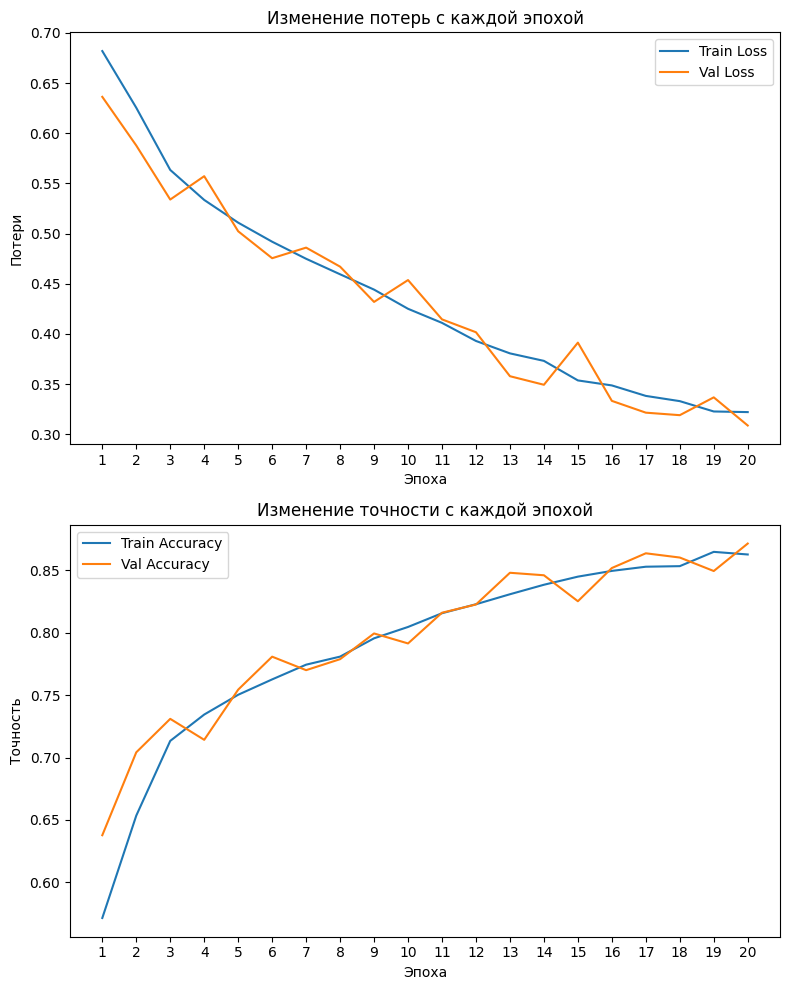

In [27]:
import matplotlib.pyplot as plt

EPOCHS = 20
epochs = range(1, EPOCHS + 1) 

plt.figure(figsize=(8, 10))

# Потери
plt.subplot(2, 1, 1)
plt.plot(epochs, history.history["loss"], label="Train Loss")
plt.plot(epochs, history.history["val_loss"], label="Val Loss")
plt.title("Изменение потерь с каждой эпохой")
plt.xlabel("Эпоха")
plt.ylabel("Потери")
plt.xticks(epochs)
plt.legend()

# Accuracy
plt.subplot(2, 1, 2)
plt.plot(epochs, history.history["accuracy"], label="Train Accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="Val Accuracy")
plt.title("Изменение точности с каждой эпохой")
plt.xlabel("Эпоха")
plt.ylabel("Точность")
plt.xticks(epochs)
plt.legend()

plt.tight_layout()
plt.savefig("plot2.svg")
plt.show()